In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import astropy.constants as c

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Models.Studies as Studies
importlib.reload(Studies)
import Plots, HODs

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Checked

## Zheng 2005

$\langle N_\text{cen} \rangle_M = \frac{1}{2} \bigg[1+\text{erf}\bigg(\frac{\log M - \log M_\text{min}}{\sigma_{\log M}}\bigg)\bigg] \qquad \text{(1)}$

$\langle N_\text{sat} \rangle_M = [(M-M_0)M_1']^\alpha \qquad \text{(3)}$

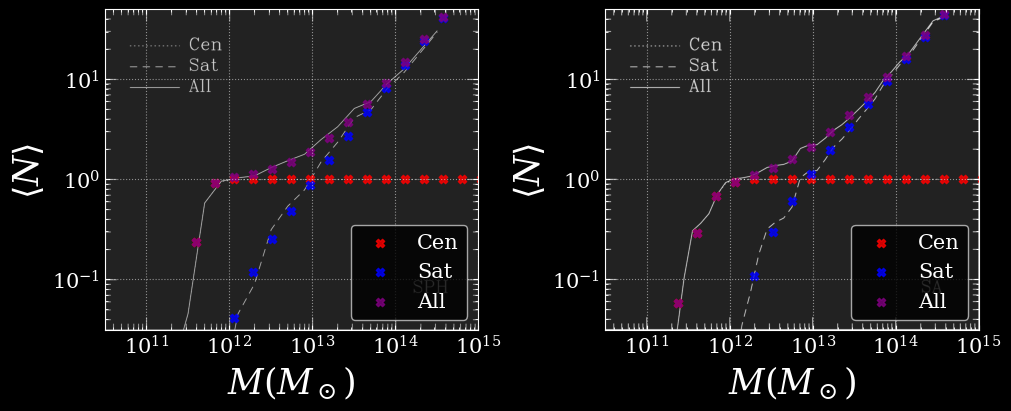

In [6]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.Zheng2005().Fig1()

logMh = np.linspace(10, 15.5, 25)

Z05 = HODs.Zheng2005(model='SPH', nparams='5P', ng='0.02')
axs[0].scatter(10**logMh, Z05.Nc(logMh)(), marker='X', c='red', alpha=0.8, label='Cen')
axs[0].scatter(10**logMh, Z05.Ns(logMh)(), marker='X', c='blue', alpha=0.8, label='Sat')
axs[0].scatter(10**logMh, Z05.Nc(logMh)()+Z05.Ns(logMh)(), marker='X', alpha=0.8, c='purple', label='All')

Z05 = HODs.Zheng2005(model='SA', nparams='5P', ng='0.02')
axs[1].scatter(10**logMh, Z05.Nc(logMh)(), marker='X', c='red', alpha=0.8, label='Cen')
axs[1].scatter(10**logMh, Z05.Ns(logMh)(), marker='X', c='blue', alpha=0.8, label='Sat')
axs[1].scatter(10**logMh, Z05.Nc(logMh)()+Z05.Ns(logMh)(), marker='X', alpha=0.8, c='purple', label='All')

axs[0].legend(loc='lower right'); axs[1].legend(loc='lower right')
plt.show()

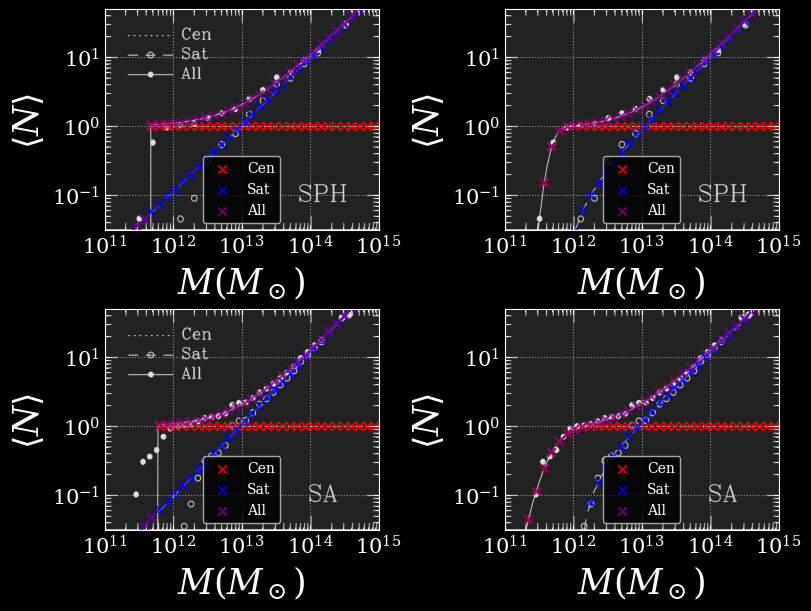

In [7]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.Zheng2005().Fig3()
axs = axs.flatten()
logMh = np.linspace(10, 15.5, 50)

configs = [("SPH", "3P"),("SPH", "5P"),("SA",  "3P"),("SA",  "5P")]
for ax, (model, nparams) in zip(axs, configs):
    Z05 = HODs.Zheng2005(model=model, nparams=nparams, ng="0.02")
    ax.scatter(10**logMh, Z05.Nc(logMh)(), marker="x", c="red", alpha=0.8, label="Cen")
    ax.scatter(10**logMh, Z05.Ns(logMh)(), marker="x", c="blue", alpha=0.8, label="Sat")
    ax.scatter(10**logMh, Z05.Nc(logMh)()+Z05.Ns(logMh)(), marker="x", c="purple", alpha=0.8, label="All")
    ax.legend(loc="lower center", fontsize=10)

plt.show()

## Kusiak 2022

$N_c(M) = \frac{1}{2} \bigg[1+\text{erf}\bigg(\frac{\log M - \log M_\text{min}^\text{HOD}}{\sigma_{\log M}}\bigg)\bigg] \qquad \text{(1)}$

$N_s(M) = N_c(M) \bigg[ \frac{M-M_0}{M_1'} \bigg] \qquad \text{(2)}$

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


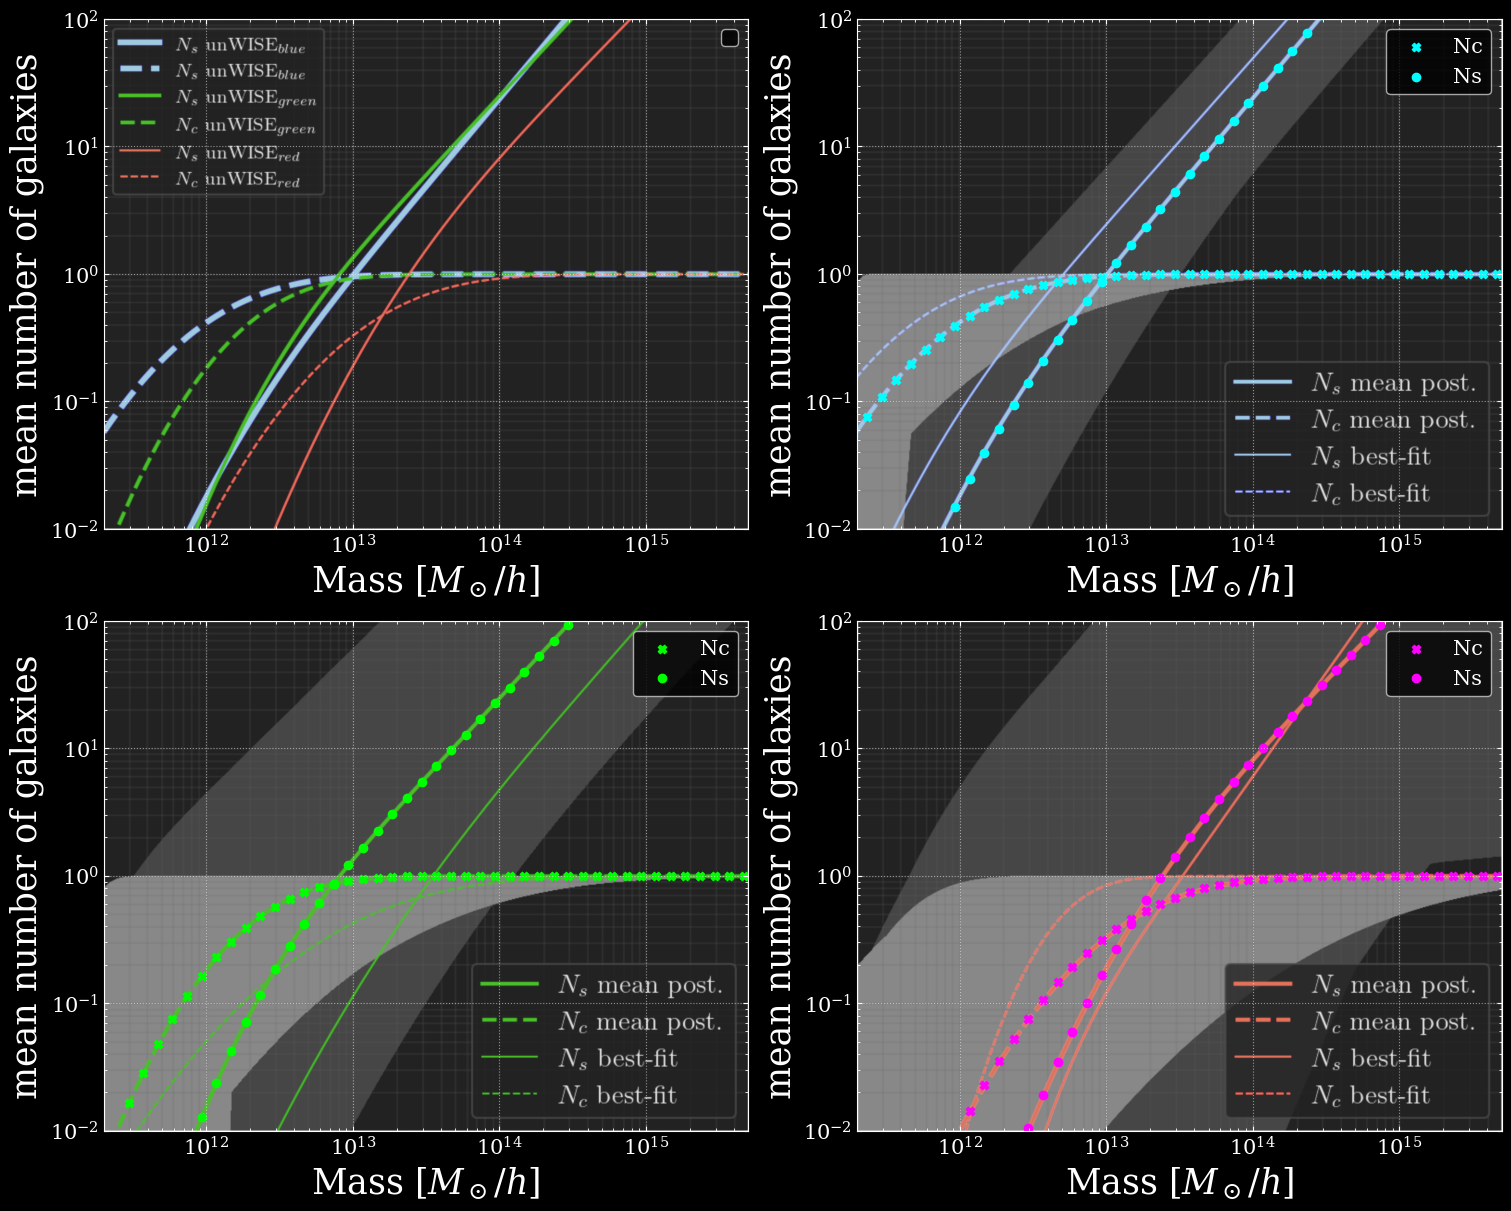

In [8]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.Kusiak2022().Fig9()
axs = axs.flatten()
logMh = np.linspace(11, 15.9, 50)

K22 = HODs.Kusiak2022({'sample':'Blue'})
axs[1].scatter(10**logMh/K22.h, K22.Nc(logMh)(), marker='X', c='cyan', label='Nc')
axs[1].scatter(10**logMh/K22.h, K22.Ns(logMh)(), c='cyan', label='Ns')

K22 = HODs.Kusiak2022({'sample':'Green'})
axs[2].scatter(10**logMh/K22.h, K22.Nc(logMh)(), marker='X', c='lime', label='Nc')
axs[2].scatter(10**logMh/K22.h, K22.Ns(logMh)(), c='lime', label='Ns')

K22 = HODs.Kusiak2022({'sample':'Red'})
axs[3].scatter(10**logMh/K22.h, K22.Nc(logMh)(), marker='X', c='magenta', label='Nc')
axs[3].scatter(10**logMh/K22.h, K22.Ns(logMh)(), c='magenta', label='Ns')

axs[0].legend(); axs[1].legend(); axs[2].legend(); axs[3].legend()
plt.show()

## Kou 2023

$\langle N_\text{c} | M \rangle = \frac{1}{2} \bigg[1+\text{erf}\bigg(\frac{\log M - \log M_\text{min}}{\sigma_{\log M}}\bigg)\bigg] f_\text{inc}(M) \qquad \text{(19)}$

$\langle N_\text{s} | M \rangle = \langle N_\text{c} | M \rangle \bigg( \frac{M-M_0}{M_1} \bigg)^{\alpha_g} \mathcal{H}(M>M_0) \qquad \text{(20)}$

$f_\text{inc}(M) = \text{max} (0, \text{min}(1+\alpha_\text{inc}(\log M - \log M_\text{inc}))) \qquad \text{(22)}$

In [1]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = Plots.Kou2023().Fig8a()
logMh = np.linspace(12, 15, 25)
pars = {'alpha_inc':0}

K23 = HODs.Kou2023({'mbin':'M1'})
ax.scatter(10**logMh, K23.Nc(logMh)(pars)+K23.Ns(logMh)(pars), alpha=0.5,c='cyan', label='M1')

K23 = HODs.Kou2023({'mbin':'M2'})
ax.scatter(10**logMh, K23.Nc(logMh)(pars)+K23.Ns(logMh)(pars), alpha=0.5,c='orange', label='M2')

K23 = HODs.Kou2023({'mbin':'M3'})
ax.scatter(10**logMh, K23.Nc(logMh)(pars)+K23.Ns(logMh)(pars), alpha=0.5,c='lime', label='M3')

K23 = HODs.Kou2023({'mbin':'M4'})
ax.scatter(10**logMh, K23.Nc(logMh)(pars)+K23.Ns(logMh)(pars), alpha=0.5,c='magenta', label='M4')

ax.legend()
plt.show()

NameError: name 'importlib' is not defined

## Yuan 2023

$\bar{n}_\text{cent}^{LRG} = \frac{f_\text{ic}}{2} \text{erfc}\bigg(\frac{\log M - \log M_\text{min}}{\sigma_{\log M}}\bigg) \qquad \text{(19)}$

$\langle N_\text{s} | M \rangle = \langle N_\text{c} | M \rangle \bigg( \frac{M-M_0}{M_1} \bigg)^{\alpha_g} \mathcal{H}(M>M_0) \qquad \text{(20)}$

In [2]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.Yuan2023().Fig7()
logMh = np.linspace(11, 15.9)

Y23 = HODs.Yuan2023(model='Ext',sample='LRG1')
axs[0].scatter(10**logMh/Y23.h, Y23.Nc(logMh)(), c='lime', label='Nc')
axs[0].scatter(10**logMh/Y23.h, Y23.Ns(logMh)(), c='magenta', label='Ns')

Y23 = HODs.Yuan2023(model='Ext',sample='LRG2')
axs[1].scatter(10**logMh/Y23.h, Y23.Nc(logMh)(), c='lime', label='Nc')
axs[1].scatter(10**logMh/Y23.h, Y23.Ns(logMh)(), c='magenta', label='Ns')

axs[0].legend(loc='lower right'); axs[1].legend(loc='lower right')
plt.show()

NameError: name 'importlib' is not defined

# All

In [ ]:
import Models.Studies as Studies
import Models.HaloModels as HaloModels
importlib.reload(Studies); importlib.reload(HaloModels)

cpars = Studies.Kusiak2022.info
hmod = HaloModels.pyccl_model({'MassDef':'200c', 'MassFunc':'Tinker08', 'HaloBias':'Tinker10', 'Concentration':'Bhattacharya13'}, **cpars)

import Models.HODs as HODs
importlib.reload(HODs)

DESI = HODs.Yuan2023({'zbin':'LRG1'})
BOSSDR12 = HODs.Kou2023({'mbin':'M1'})
unWISE = HODs.Kusiak2022({'sample':'Red'})
KV450xG = HODs.Linke2022({'sample':'MS', 'color':'r'})
BOSSDR11 = HODs.More2015({'mbin':'MA'})

logMs = np.geomspace(10, 15)
logM500c, logMs200m = hmod.logM_conv(z, logMs, '500c'), hmod.logM_conv(z, logMs, '200m')

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex=True)
axs = axs.flatten()

axs[0].plot(logMs, DESI.Nc(logMs)(), label='DESI 1%')
axs[1].plot(logMs, DESI.Ns(logMs)(), label='DESI 1%')

axs[0].plot(logMs200m, BOSSDR12.Nc(logMs200m)(), label='BOSS DR12')
axs[1].plot(logMs200m, BOSSDR12.Ns(logMs200m)(), label='BOSS DR12')

axs[0].plot(logMs, unWISE.Nc(logMs)(), label='unWISE')
axs[1].plot(logMs, unWISE.Ns(logMs)(), label='unWISE')

axs[0].plot(logMs200m, KV450xG.Nc(logMs200m)(), label='KV450xGAMA')
axs[1].plot(logMs200m, KV450xG.Ns(logMs200m)(), label='KV450xGAMA')

axs[0].plot(logMs200m, BOSSDR11.Nc(logMs200m)(), label='BOSS DR11')
axs[1].plot(logMs200m, BOSSDR11.Ns(logMs200m)(), label='BOSS DR11')

axs[0].set(ylabel=r'$\overline{N_c} (M_h) \ []$', xlabel=r'log$M_h \ [M_\odot]$', xlim=(11, 15)); axs[0].legend()
axs[1].set(ylabel=r'$\overline{N_s} (M_h) \ []$', xlabel=r'log$M_h \ [M_\odot]$', yscale='log', ylim=(1e-4, 1e3)); axs[1].legend()

plt.show()

In [ ]:
import Models.Studies as Studies
import Models.HaloModels as HaloModels
importlib.reload(Studies); importlib.reload(HaloModels)

cpars = Studies.Kusiak2022.info
hmod = HaloModels.pyccl_model({'MassDef':'200c', 'MassFunc':'Tinker08', 'HaloBias':'Tinker10', 'Concentration':'Bhattacharya13'}, **cpars)

import Models.HODs as HODs
importlib.reload(HODs)

Yuan = HODs.Yuan2023({'zbin':'LRG1'}, r200m=hmod.rdel('200m'), c200m=hmod.c, **cpars)
Kou = HODs.Kou2023({'mbin':'M1'}, r200m=hmod.rdel('200m'), c200m=hmod.c, **cpars)
Kusiak = HODs.Kusiak2022({'sample':'Red'}, rhom=hmod.rhoc, r200c=hmod.rdel('200c'), c200c=hmod.c, **cpars)
Linke = HODs.Linke2022({'sample':'MS', 'color':'r'}, rhoc=hmod.rhoc, r200m=hmod.rdel('200m'), c200m=hmod.c, **cpars)
More = HODs.More2015({'mbin':'MA'}, r200m=hmod.rdel('200m'), c200m=hmod.c, **cpars)

In [ ]:
ks, z, logM = np.geomspace(1e-2, 1e2, 500), 0.55, 12.5
rs = np.geomspace(1e-2, 1e2, 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex=True)
axs = axs.flatten()

# axs[0].plot(rs, Kou.ns_r(rs, z, logM)()[:, 0, 0], alpha=0.8,label='Kou 2023')
# axs[1].plot(ks, Kou.ns(ks, z, logM)()[:, 0, 0], alpha=0.8, label='Kou 2023')

axs[1].plot(ks, Kusiak.ns(ks, z, logM)()[:, 0, 0],alpha=0.8, label='Kusiak 2022')

# axs[0].plot(rs, Linke.ns_r(rs, z, logM)()[:, 0, 0], alpha=0.8, label='Linke 2022')
# axs[1].plot(ks, Linke.ns(ks, z, logM)()[:, 0, 0], alpha=0.8,label='Linke 2022')


axs[0].set(ylabel=r'$\hat{n}_s (r, z, M_h) \ [\text{Mpc}^{-3}]$', xlabel=r'$r \ [\text{Mpc}]$', xscale='log', yscale='log'); axs[0].legend()
axs[1].set(ylabel=r'$\hat{n}_s (k, z, M_h) \ [\text{Mpc}^{-3}]$', xlabel=r'$k \ [\text{Mpc}^{-1}]$', yscale='log'); axs[1].legend()

plt.show()

# Unchecked

## More 2015

$\langle N \rangle_M = \langle N_c \rangle_M + \langle N_s \rangle_M \qquad \text{(2)}$

$\langle N_c \rangle_M = f_\text{inc}(M)\frac{1}{2} \bigg[1+\text{erf}\bigg(\frac{\log M - \log M_\text{min}}{\sigma_{\log M}}\bigg)\bigg] \qquad \text{(3)}$

$\langle N_s \rangle_M = \langle N_s \rangle_M \bigg[ \frac{M-\kappa M_\text{min}}{M_1}\bigg]^\alpha \qquad \text{(4)}$

$f_\text{inc}(M) = \text{max} \Big[ 0, \text{min} \big[1, 1+\alpha_\text{inc} (\log M - \log M_\text{inc}) \big] \Big] \qquad \text{(5)}$

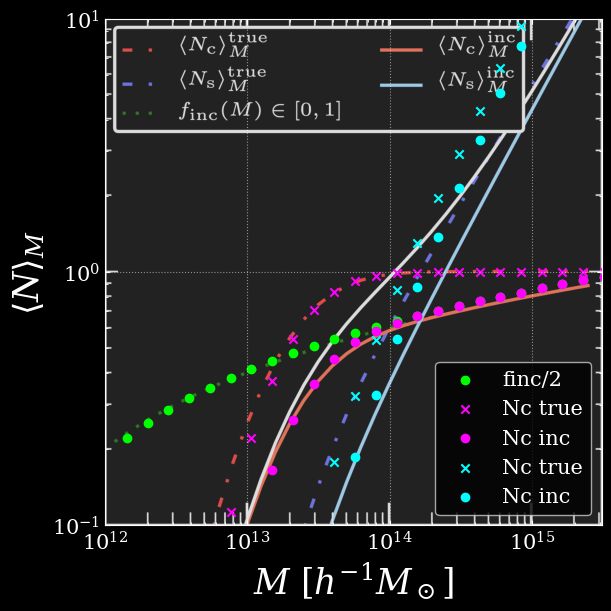

In [119]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = Plots.More2015().Fig2()
logMh = np.linspace(12, 15.5, 25)

M15 = HODs.More2015(mbin='MA')

p=M15.p0

finc_func = lambda logM: lambda p=M15.p0: (1+p['alpha_inc']*((logM-np.log10(M15.h**2))-p['logM_inc']))/2
ax.scatter(10**logMh/M15.h, finc_func(logMh)(p), c='lime', label='finc/2')

ax.scatter(10**logMh/M15.h, M15.Nc(logMh)(p)/finc_func(logMh)(p), c='magenta', marker='x', label='Nc true')
ax.scatter(10**logMh/M15.h, M15.Nc(logMh)(p), c='magenta', marker='o', label='Nc inc')

ax.scatter(10**logMh/M15.h, M15.Ns(logMh)(p)/finc_func(logMh)(p), c='cyan', marker='x', label='Nc true')
ax.scatter(10**logMh/M15.h, M15.Ns(logMh)(p), c='cyan', marker='o', label='Nc inc')

ax.legend(loc='lower right')
plt.show()

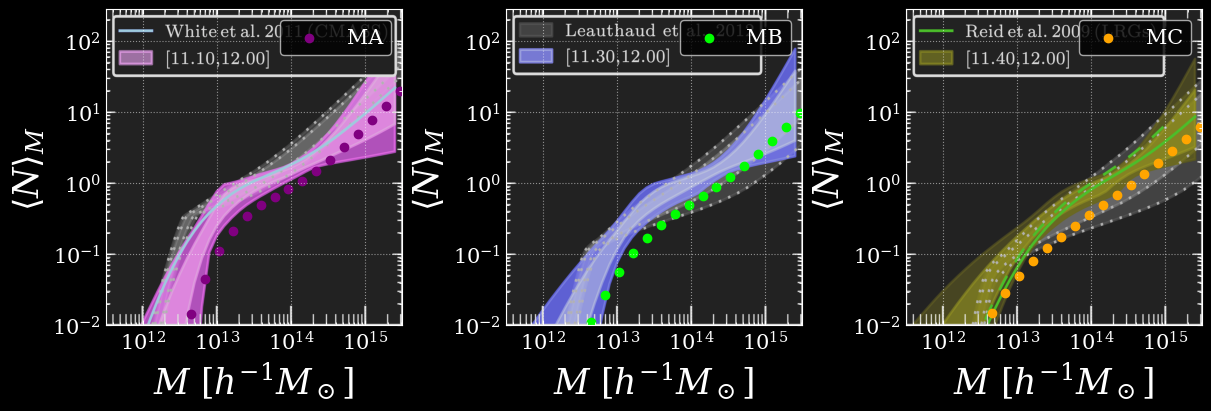

In [12]:
importlib.reload(Plots); importlib.reload(HODs)
fig, axs = Plots.More2015().Fig4()
logMh = np.linspace(11, 15.5, 25)
pars = {'alpha_inc':0}

M15 = HODs.More2015({'mbin':'MA'})
axs[0].scatter(10**logMh/M15.h, M15.Nc(logMh)(pars)+M15.Ns(logMh)(pars),c='purple', label='MA')

M15 = HODs.More2015({'mbin':'MB'})
axs[1].scatter(10**logMh/M15.h, M15.Nc(logMh)(pars)+M15.Ns(logMh)(pars),c='lime', label='MB')

M15 = HODs.More2015({'mbin':'MC'})
axs[2].scatter(10**logMh/M15.h, M15.Nc(logMh)(pars)+M15.Ns(logMh)(pars),c='orange', label='MC')

axs[0].legend(); axs[1].legend(); axs[2].legend()
plt.show()

## Yuan 2023

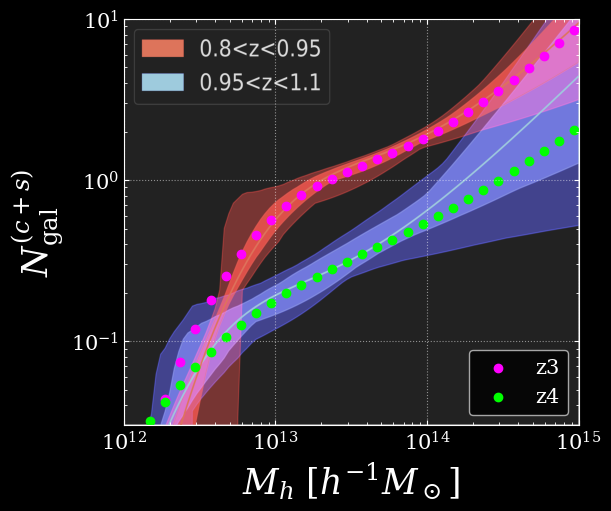

In [32]:
importlib.reload(Plots); importlib.reload(HODs)
fig, ax = Plots.Yuan2023().Fig10()

logMh = np.linspace(11, 15.9)

Y23_3 = HODs.Yuan2023(model='Base',sample='LRG3')
ax.scatter(10**logMh/Y23_3.h, Y23_3.Nc(logMh)()+Y23_3.Ns(logMh)(), c='magenta', label='z3')

Y23_4 = HODs.Yuan2023(model='Base',sample='LRG4')
ax.scatter(10**logMh/Y23_4.h, Y23_4.Nc(logMh)()+Y23_4.Ns(logMh)(), c='lime', label='z4')

ax.legend(loc='lower right')
plt.show()

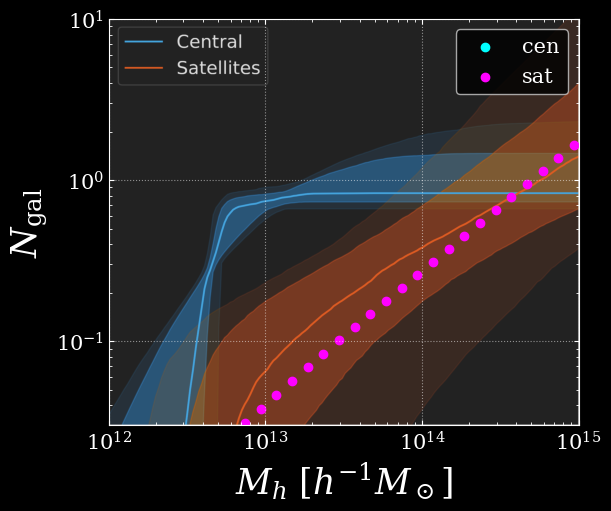

In [13]:
importlib.reload(Plots); importlib.reload(HODs)

fig, ax = Plots.Yuan2023().Fig14()

logMh = np.linspace(11, 15.9)

Yuan2023 = HODs.Yuan2023(model='Ext',sample='QSO')
ax.scatter(10**logMh/Yuan2023.h, Yuan2023.Nc(logMh)(), c='cyan', label='cen')
ax.scatter(10**logMh/Yuan2023.h, Yuan2023.Ns(logMh)(), c='magenta', label='sat')

ax.legend()
plt.show()

## Kusiak 2022

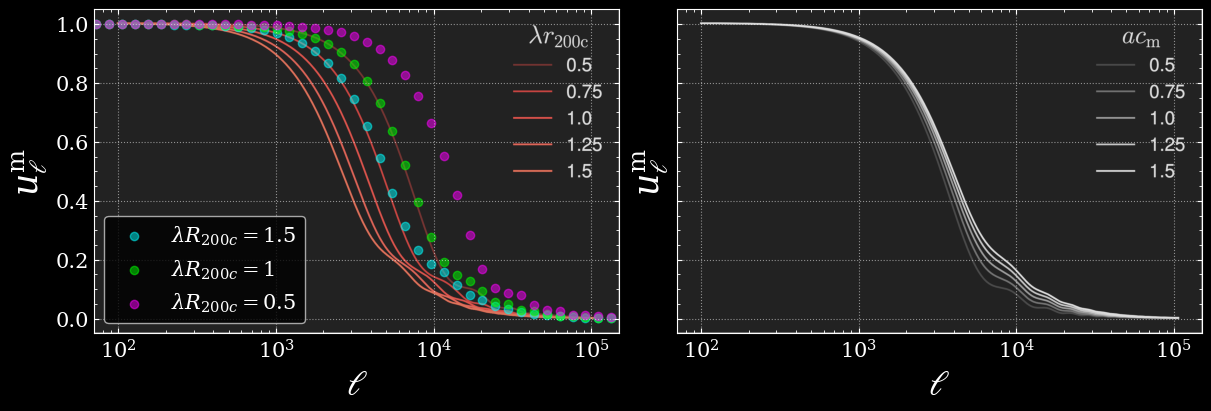

In [ ]:
fig, axs = Plots.Kusiak2022().Fig15()

import HODs, HaloModels
import Studies
import Models.Studies as Studies

importlib.reload(Studies)
importlib.reload(HODs); importlib.reload(HaloModels)

hmod = HaloModels.colossus_model(**HODs.Kusiak2022().info)

ks = np.geomspace(1e-2, 1e2)

z, logMh = 0.5, np.log10(3e14/HODs.Kusiak2022().h)
c200c0, ells0 = 3.4, ks*(1317/HODs.Kusiak2022().h)-0.5
ells = ks/u.Mpc*hmod.chi(z)-0.5
r200c = hmod.rdel('200c')(z, logMh).value
prefac = 10**logMh*u.Msun/hmod.rhom(0)

Kusiak2022 = HODs.Kusiak2022({'sample':'Blue'}, rhom=hmod.rhom, r200c=hmod.rdel('200c'), c200c=hmod.c)
axs[0].scatter(ells, Kusiak2022.nsat(ks, z, logMh)({'Lambda':1.5/r200c})[:, 0, 0]/prefac, color='cyan', alpha=0.5, label=r'$\lambda R_{200c}=1.5$')
axs[0].scatter(ells, Kusiak2022.nsat(ks, z, logMh)({'Lambda':1/r200c})[:, 0, 0]/prefac, color='lime', alpha=0.5, label=r'$\lambda R_{200c}=1$')
axs[0].scatter(ells, Kusiak2022.nsat(ks, z, logMh)({'Lambda':0.5/r200c})[:, 0, 0]/prefac, color='magenta', alpha=0.5, label=r'$\lambda R_{200c}=0.5$')

axs[0].legend(loc='lower left')
plt.show()

## Linke 2022

In [2]:
import Models.Studies as Studies
importlib.reload(Studies)
import Models.HODs as HODs
importlib.reload(HODs)

<module 'Models.HODs' from '/global/homes/c/cpopik/CAPPIBARAS/Models/HODs.py'>

TypeError: unsupported operand type(s) for ** or pow(): 'dict' and 'int'

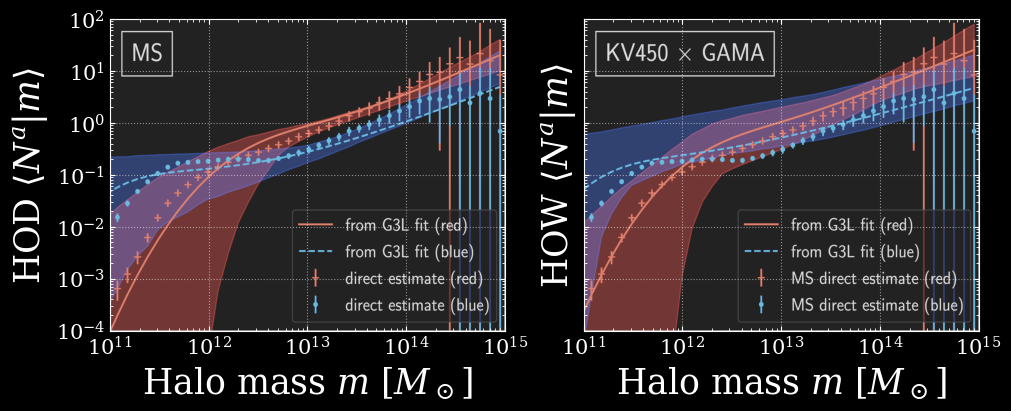

In [3]:
fig, axs = Plots.Linke2022().Fig8()

import Models.HODs as HODs
importlib.reload(HODs)

logMh = np.linspace(11, 15)
Linke2022 = HODs.Linke2022({'sample':'MS', 'color':'r'})
axs[0].plot(10**logMh, Linke2022.Nc(logMh)()+Linke2022.Ns(logMh)(), lw=3, ls='--',c='magenta', label='mine')
Linke2022 = HODs.Linke2022({'sample':'MS', 'color':'b'})
axs[0].plot(10**logMh, Linke2022.Nc(logMh)()+Linke2022.Ns(logMh)(), lw=3, ls='--',c='lime', label='mine')

Linke2022 = HODs.Linke2022({'sample':'KVG', 'color':'r'})
axs[1].plot(10**logMh, Linke2022.Nc(logMh)()+Linke2022.Ns(logMh)(), lw=3, ls='--',c='magenta', label='mine')
Linke2022 = HODs.Linke2022({'sample':'KVG', 'color':'b'})
axs[1].plot(10**logMh, Linke2022.Nc(logMh)()+Linke2022.Ns(logMh)(), lw=3, ls='--',c='lime', label='mine')

ax.legend()
plt.show()

TypeError: unsupported operand type(s) for ** or pow(): 'dict' and 'int'

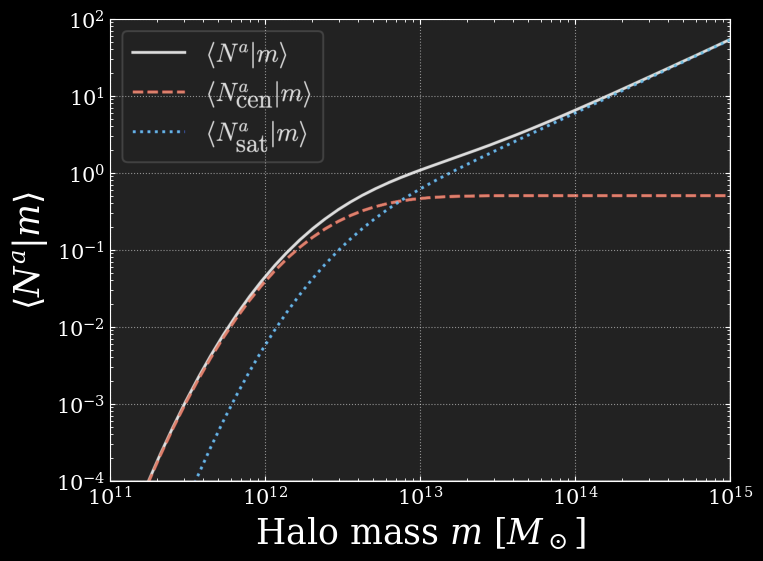

In [ ]:
fig, ax = Plots.Linke2022().Fig2()

import HODs
importlib.reload(HODs)

logMh = np.linspace(11, 15.5)
Linke2022 = HODs.Linke2022({'sample':'MS', 'color':'r'})
pfid = {'alpha_a':0.5, 'sigma_a':0.5, 'M_th_a':12.5, 'beta_a':1, 'M_a':13.5}
ax.scatter(10**logMh, Linke2022.Nc(logMh)(pfid),c='magenta', label='cen')
ax.scatter(10**logMh, Linke2022.Ns(logMh)(pfid), c='cyan', label='sat' )
ax.scatter(10**logMh, Linke2022.Nc(logMh)(pfid)+Linke2022.Ns(logMh)(pfid), c='w', label='tot')

ax.legend()
plt.show()

## Hadzhiyska 2025B

In [5]:
import Models.Studies as Studies
importlib.reload(Studies)

Studies.More2015()

TypeError: unsupported operand type(s) for ** or pow(): 'dict' and 'int'

In [39]:
def cycle(d, f):
    if not isinstance(d, dict): # if the input isn't a dictionary
        return f(d) # just return function applied to the value
    else: # if the input is a dictionary
        outdict={} # make a new dictionary
        for k, v in d.items(): # for every key and value in the input dict
            if not isinstance(v, dict): # if the value is not a dict
                outdict[k] = f(v)  # apply the function as the new value
            else: # if the value IS a dict
                outdict[k] = cycle(v, f)  # repeat this function recursively
        return outdict  # return the function where every key of the dict has the function applied
    
dtest = {'a':{'m1':1, 'm2':2},
         'b':{'m1':{'z1':3, 'z2':4}, 'm2':{'z1':5, 'z2':6}},
         'c':{'z1':7, 'z2':8}}

cycle(dtest['a'], lambda a: a+1)

{'m1': 2, 'm2': 3}

In [68]:
def spefinfo(info, input):
    try: info = info[input]  # try to narrow down the current info input
    except: pass  # leave as is otherwise
    if not isinstance(info, dict): return info  # if it's not a dict, return the value
    return {k: spefinfo(v, input) for k, v in info.items()}  # otherwise recursively rebuild the dict

In [69]:
dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}

In [135]:
dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}

def all_keys(d):
    return [k for k in d.keys()] + [kk for v in d.values() if isinstance(v, dict) for kk in all_keys(v)]
    
all_keys(dtest2)

['a', 'b', 'm1', 'm2', 'z1', 'z2', 'm1', 'm2', 'm1', 'm2']

In [155]:
[x for v in subs.values() for x in v]

['m1', 'm2', 'z1', 'z2', 'q1', 'q2']

In [293]:
# def cycle2(d, f):
#     try:  # try to apply the function normally
#         # print('yay!', f(d))
#         return f(d)
#     except:  # if it failed, one value is still a dict
#         # print('WAH!')
#         outdict = {}
#         for k, v in d.items(): # for every parameter
#             if not isinstance(v, dict): # if the parameter isn't a dict
#                 pass  # ignore it, it's fine 
#             else: # if the parameter IS a dict
#                 for k2 in v.keys():  # for every key in the parameter dict
#                     newdict = spefinfo(d, k2)
#                     outdict[k2] = cycle2(newdict, f)
#         # print('yay?', outdict)
#         return outdict


def cycle2(d, f):
    argnames = list(inspect.signature(f).parameters)
    try: return f(*[d[p] for p in argnames])  # try to apply the function normally
    except:  # if it failed, one value is still a dict
        def all_keys(d):
            return [k for k in d.keys()] + [kk for v in d.values() if isinstance(v, dict) for kk in all_keys(v)]
        unique_keys = list(dict.fromkeys(k for p in argnames for k in (all_keys(d[p]) if isinstance(d[p], dict) else [])))
        
        outdict={}
        for v in unique_keys:
            if spefinfo(d, v)==d: continue # if nothing was specified, skip it
            elif v not in all_keys(outdict): # if something was specific, make a new key for it
                outdict[v] = cycle2(spefinfo(d, v), f)
        return outdict

dtest2 = {'a': 1, 'b': 2}
print('Output:', cycle2(dtest2, lambda a, b: a+b)) 

dtest2 = {'a': 1, 'b': {'z1':1, 'z2':2}}
print('Output:', cycle2(dtest2, lambda a,b: a+b))

dtest2 = {'a': {'z1':4, 'z2':6}, 'b': {'z1':1, 'z2':2}}
print('Output:', cycle2(dtest2, lambda a, b: a+b))

dtest2 = {'a': 1, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}
print('Output:', cycle2(dtest2, lambda a, b: a+b))

dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}
print('Output:', cycle2(dtest2, lambda a,b: a+b))

dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':3, 'z2':5}}
print('Output:', cycle2(dtest2, lambda a,b: a+b))

dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':3, 'z2':5}}
print('Output:', cycle2(dtest2, lambda a: a*2)) 

Output: 3
Output: {'z1': 2, 'z2': 3}
Output: {'z1': 5, 'z2': 8}
Output: {'z1': {'m1': 3, 'm2': 4}, 'z2': {'m1': 5, 'm2': 6}}
Output: {'m1': {'z1': 4, 'z2': 6}, 'm2': {'z1': 6, 'z2': 8}}
Output: {'m1': {'z1': 5, 'z2': 7}, 'm2': {'z1': 6, 'z2': 8}}
Output: {'m1': 4, 'm2': 6}


In [282]:

def all_keys(d):
    return [k for k in d.keys()] + [kk for v in d.values() if isinstance(v, dict) for kk in all_keys(v)]

dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}
argnames = list(inspect.signature(lambda a,b: a+b).parameters)
unique_keys = list(dict.fromkeys(k for p in argnames for k in (all_keys(dtest2[p]) if isinstance(dtest2[p], dict) else [])))

unique_keys

['m1', 'm2', 'z1', 'z2']

In [ ]:
list(set(k for sublist in lists for k in sublist))

In [251]:
func=lambda a: a*2

import inspect
list(inspect.signature(func).parameters)

['a']

In [248]:
argnames

['d']

In [ ]:
dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':3, 'z2':5}}
dtest2 = {'a':{'m1':2, 'm2':3}, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}
dtest2 = {'a': 1, 'b': {'z1':{'m1':2, 'm2':3}, 'z2':{'m1':4, 'm2':5}}}
dtest2 = {'a': 1, 'b': {'z1':1, 'z2':2}}
dtest2 = {'a': 1, 'b': 2, 'c':{'z1':1, 'z2':1}}


In [247]:
func = lambda d: d['a']*2

In [ ]:
def cycle2(d, f):
    try:  # try to apply the function onto the key of the dict
        print(f(d))
    except: # if we fail to apply the fucntion onto the key of the dict, one of more of the parameters into it is still a dict


cycle(dtest, lambda d: d['a']+1)

TypeError: 'int' object is not subscriptable

In [ ]:
models = {'mass':['m1', 'm2'],
          'zpho':['z1', 'z2']}
dtest = {'a':{'m1':1, 'm2':2},
         'b':{'m1':{'z1':3, 'z2':4}, 'm2':{'z1':5, 'z2':6}},
         'c':{'z1':7, 'z2':8}}

